In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("data")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
df.info()
df.shape
df.describe()
df.columns
df.isnull().sum()
df.duplicated().sum()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [4]:
#DATA PREPROCESSING
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst = True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"],dayfirst= True)
df.info()
df.head()
#shipping days
df[["Order Date","Ship Date"]].head()
df["Order Year"] =  df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Day"] = df["Order Date"].dt.day
df["Order Weekday "] = df["Order Weekday"] = df["Order Date"].dt.day_name()
df.head()
df["Profit Margin"] = df["Gross Profit"]/df["Sales"]
df.head()
df["Sales Per Unit"] = df["Sales"]/df["Units"]
df[["Sales Per Unit","Sales","Units"]].head()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  str           
 10  Division        10194 non-null  str           
 11  Region          10194 non-null  str           
 12  Product ID      10194 non-null  str           
 13  Product Name    10194 non-null  str           
 14  Sales           10194 non-null  float64       
 15  Units        

,Row ID,Order Date,Ship Date,Customer ID,Sales,Units,Gross Profit,Cost,Order Year,Order Month,Order Day,Profit Margin,Sales Per Unit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-03-13 03:08:26.415538,2028-10-23 23:20:43.790465,134468.961154,13.908537,3.791838,9.166451,4.742087,2024.589857,7.811850,15.445066,0.665140,3.654257
min,1.000000,2024-01-02 00:00:00,2026-06-30 00:00:00,100006.000000,1.250000,1.000000,0.250000,0.600000,2024.000000,1.000000,1.000000,0.076923,1.250000
25%,2549.250000,2024-09-28 00:00:00,2027-11-09 00:00:00,117212.000000,7.200000,2.000000,4.900000,2.400000,2024.000000,5.000000,8.000000,0.653333,3.490000
50%,5097.500000,2025-04-06 12:00:00,2028-12-18 00:00:00,133550.000000,10.800000,3.000000,7.470000,3.600000,2025.000000,9.000000,15.000000,0.666667,3.600000
75%,7645.750000,2025-09-16 00:00:00,2029-11-08 00:00:00,152051.000000,18.000000,5.000000,12.250000,5.700000,2025.000000,11.000000,23.000000,0.694444,3.600000
max,10194.000000,2025-12-31 00:00:00,2030-06-28 00:00:00,192314.000000,260.000000,14.000000,130.000000,130.000000,2025.000000,12.000000,31.000000,0.800000,20.000000
std,2942.898656,NaN,NaN,20231.483007,11.341020,2.228317,6.643740,5.061647,0.491884,3.295915,8.729661,0.067210,1.611875


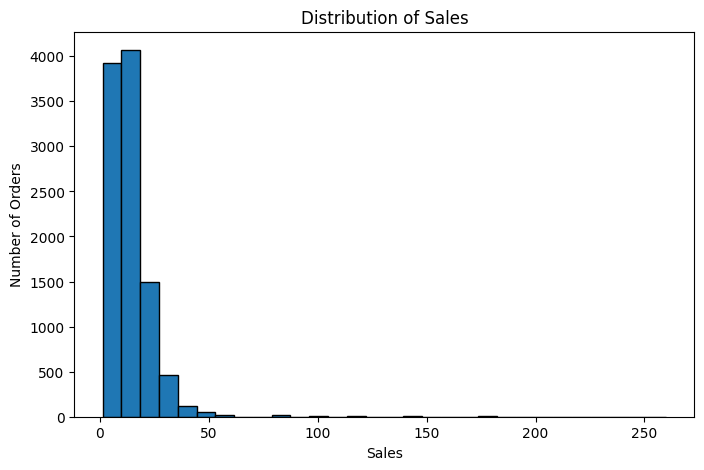

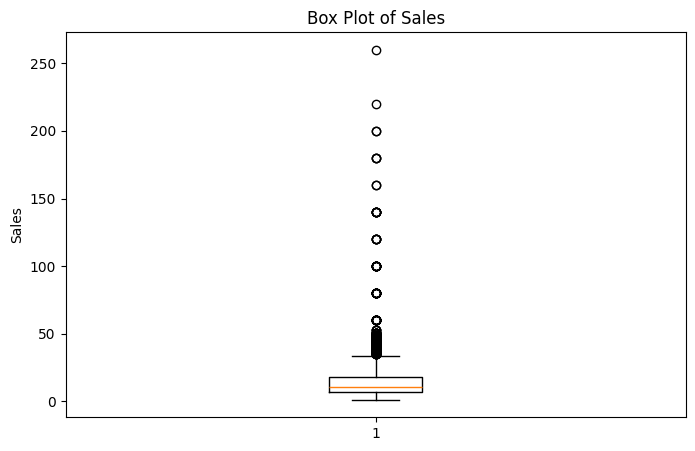

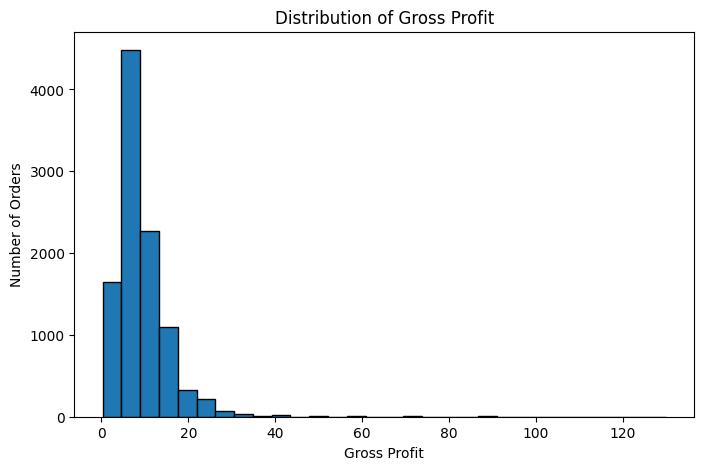

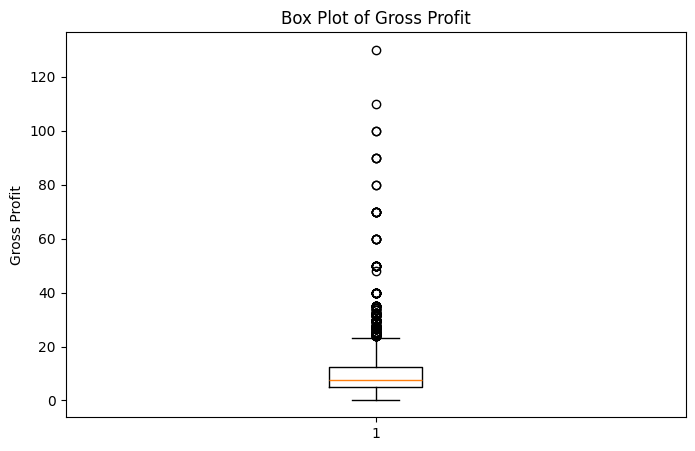

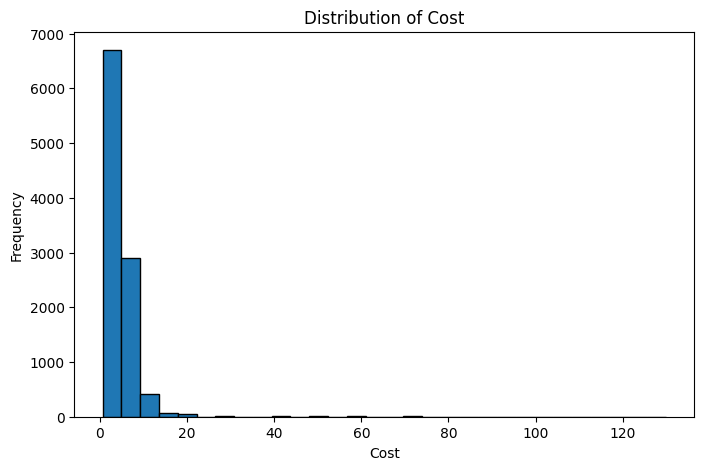

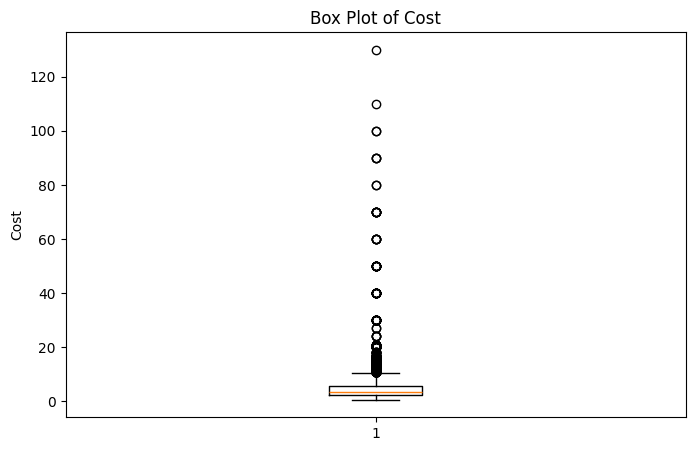

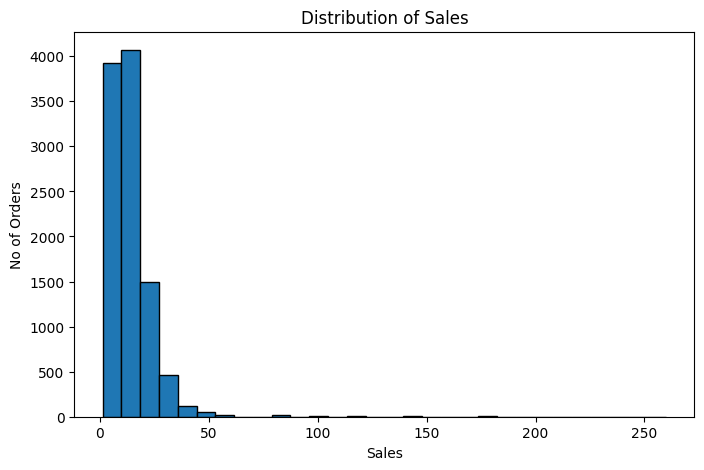

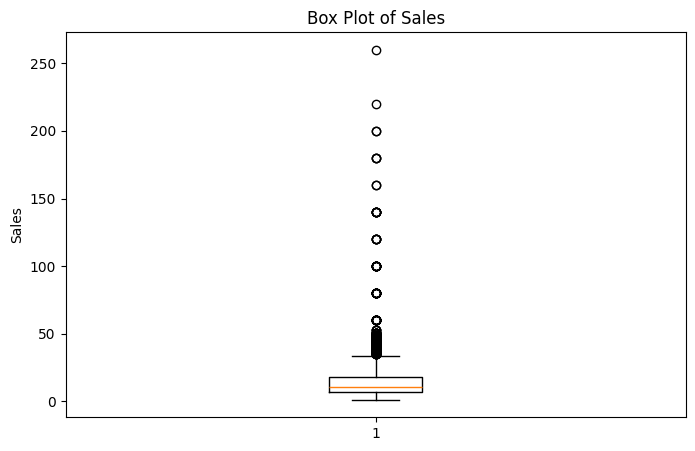

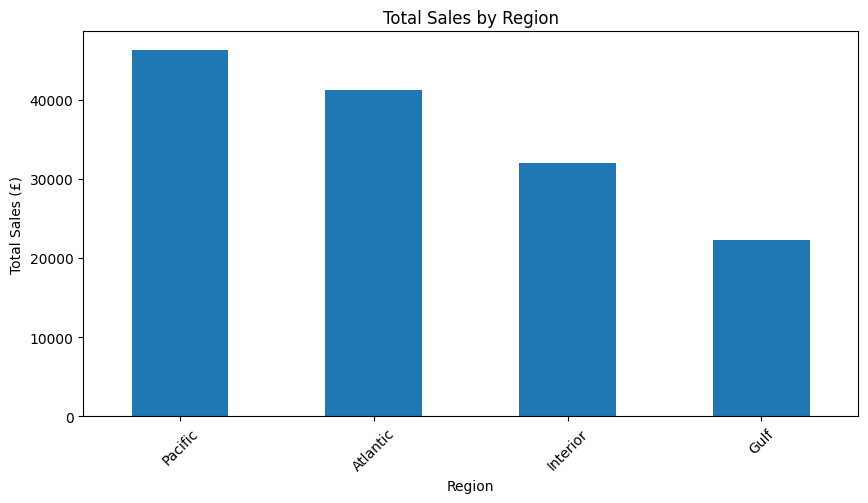

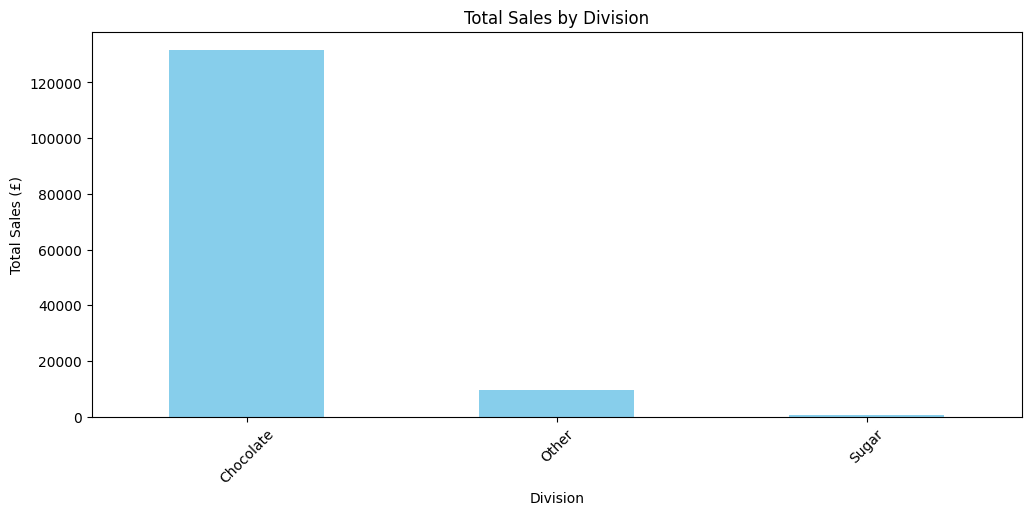

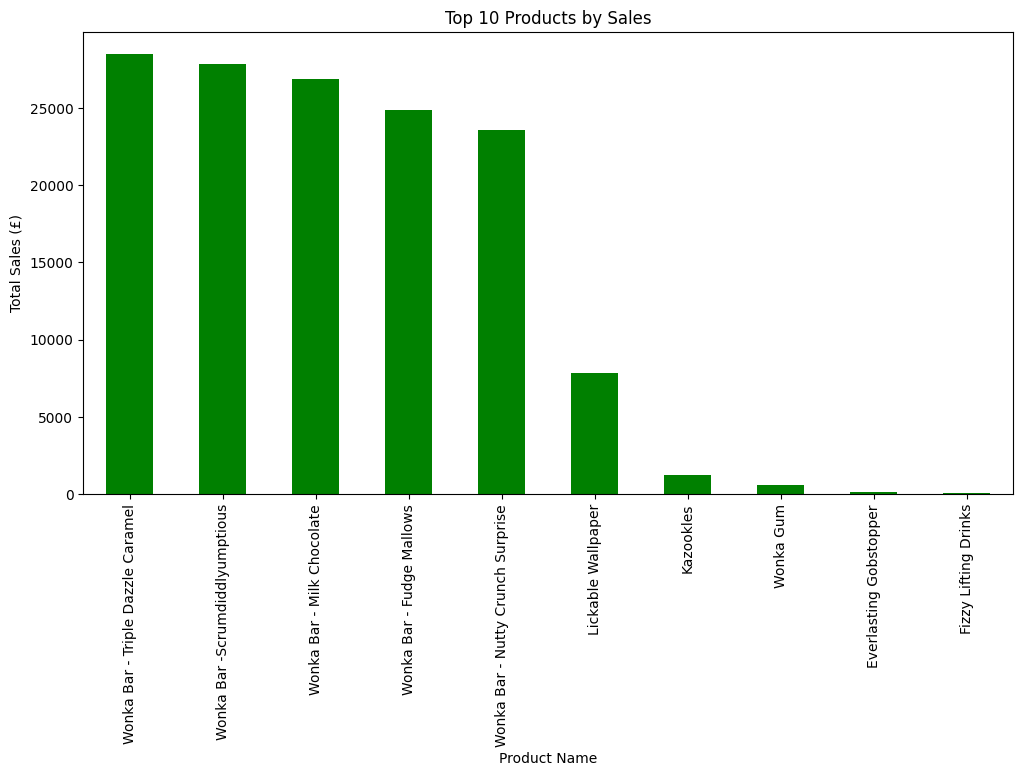

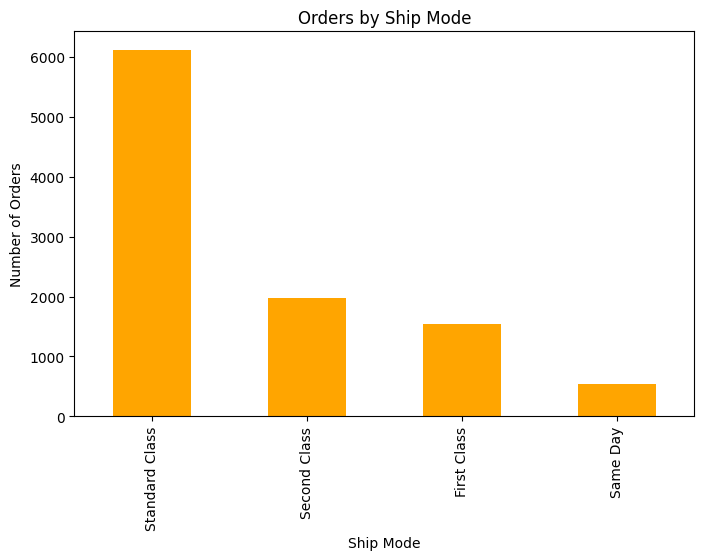

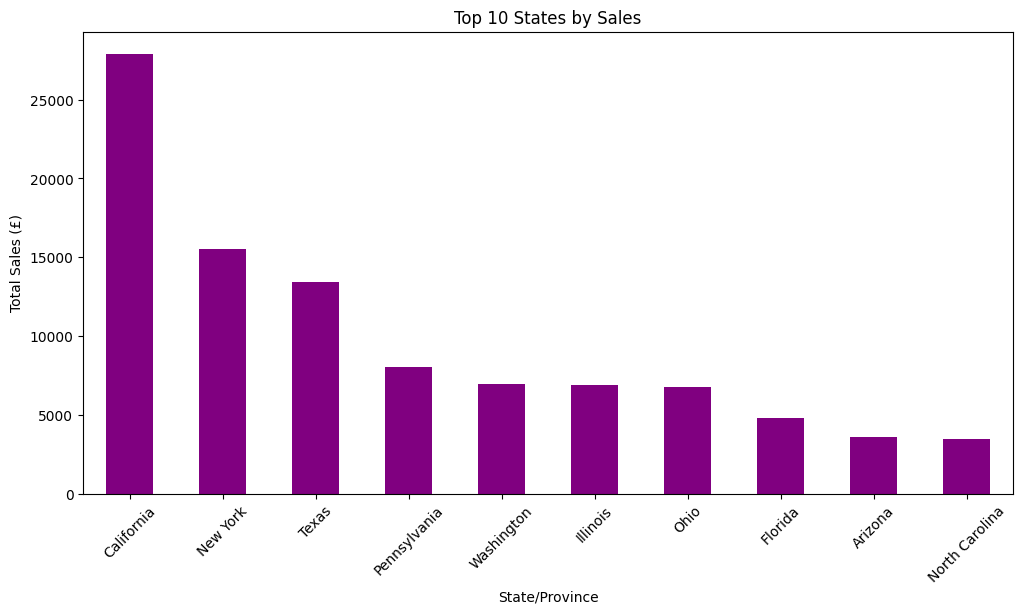

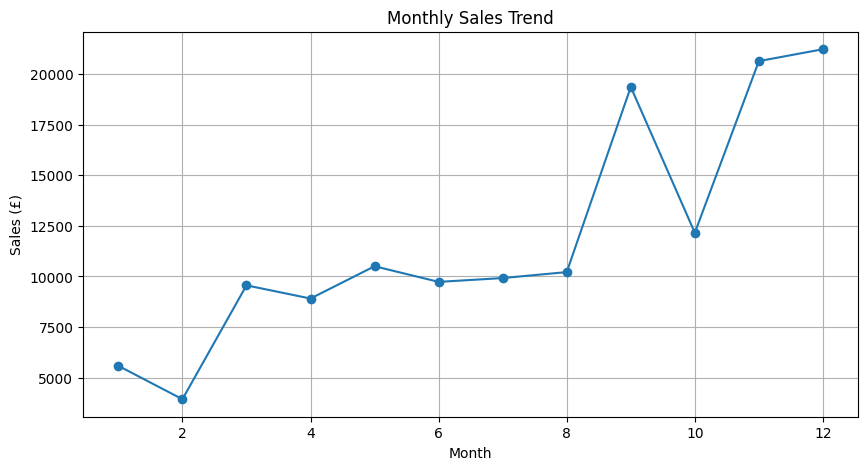

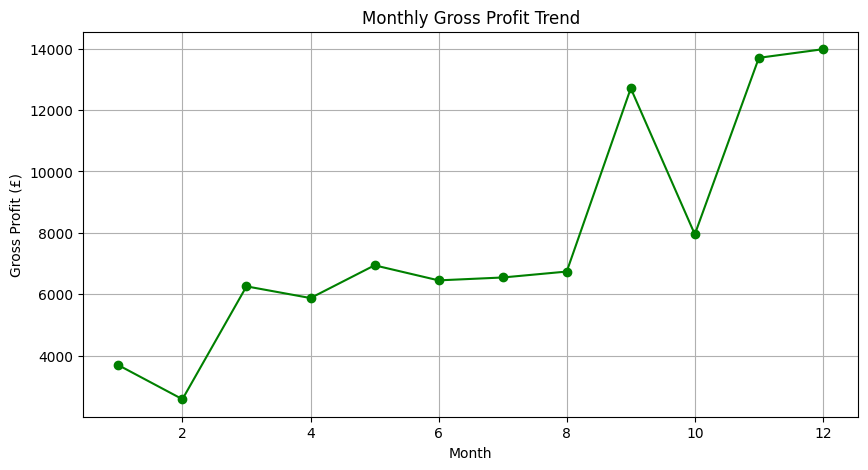

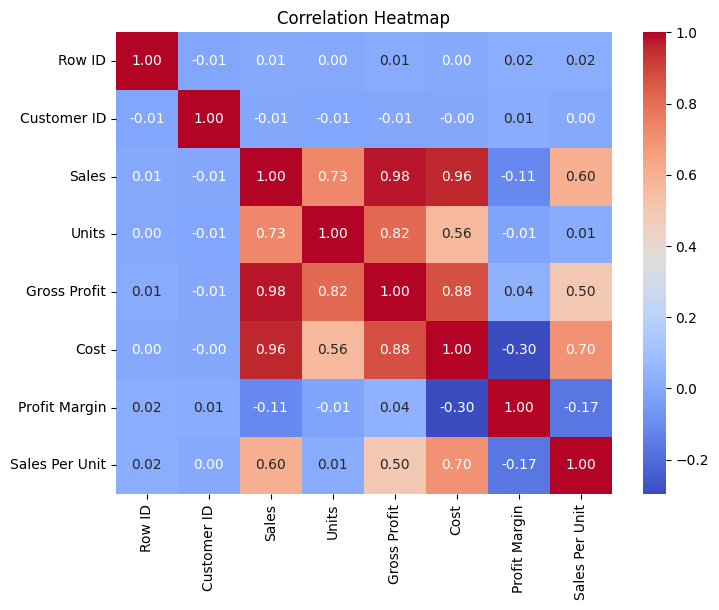

In [5]:
#EDA
#Histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30, edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.show()

#box plots

plt.figure(figsize=(8,5))
plt.boxplot(df["Sales"])
plt.title("Box Plot of Sales")
plt.ylabel("Sales")
plt.show()

#gross profit distribution
plt.figure(figsize=(8,5))
plt.hist(df["Gross Profit"], bins=30, edgecolor="black")
plt.title("Distribution of Gross Profit")
plt.xlabel("Gross Profit")
plt.ylabel("Number of Orders")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["Gross Profit"])
plt.title("Box Plot of Gross Profit")
plt.ylabel("Gross Profit")
plt.show()
#cost distribution
plt.figure(figsize=(8,5))
plt.hist(df["Cost"], bins=30, edgecolor="black")
plt.title("Distribution of Cost")
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["Cost"])
plt.title("Box Plot of Cost")
plt.ylabel("Cost")
plt.show()

#sales distribution
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30, edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("No of Orders")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["Sales"])
plt.title("Box Plot of Sales")
plt.ylabel("Sales")
plt.show()

#region wise  sales analysis
import matplotlib.pyplot as plt
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=45)
plt.show()

#division wise sales
division_sales = df.groupby("Division")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
division_sales.plot(kind="bar", color="skyblue")
plt.title("Total Sales by Division")
plt.xlabel("Division")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=45)
plt.show()

#top 10 products
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar", color="green")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=90)
plt.show()

#sales by ship mode
ship_mode = df["Ship Mode"].value_counts()

plt.figure(figsize=(8,5))
ship_mode.plot(kind="bar", color="orange")
plt.title("Orders by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Orders")
plt.show()

#state wise analysis
state_sales = (
    df.groupby("State/Province")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
state_sales.plot(kind="bar", color="purple")
plt.title("Top 10 States by Sales")
plt.xlabel("State/Province")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=45)
plt.show()

#monthly sales trend
monthly_sales = df.groupby("Order Month")["Sales"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (£)")
plt.grid(True)
plt.show()

#monthly gross profit trend
monthly_profit = df.groupby("Order Month")["Gross Profit"].sum()

plt.figure(figsize=(10,5))
monthly_profit.plot(marker="o", color="green")
plt.title("Monthly Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Gross Profit (£)")
plt.grid(True)
plt.show()

#correlation heatmap
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

(8155, 7)
(2039, 7)
(8155,)
(2039,)
MAE: 0.7287635427382251
RMSE: 1.6102818036560451
R2: 0.9329534324015709
Random Forest Results
------------------------------
MAE : 0.010244237371266795
MSE : 0.036302273908778826
RMSE: 0.1905315562020602
R² Score: 0.9990613436815629
Linear Regression R² : 0.9329534324015709
Random Forest R²     : 0.9990613436815629
          Feature  Importance
5            Cost    0.796922
4           Units    0.154409
2    Product Name    0.035972
1        Division    0.011121
3  State/Province    0.000977
0          Region    0.000409
6     Order Month    0.000189


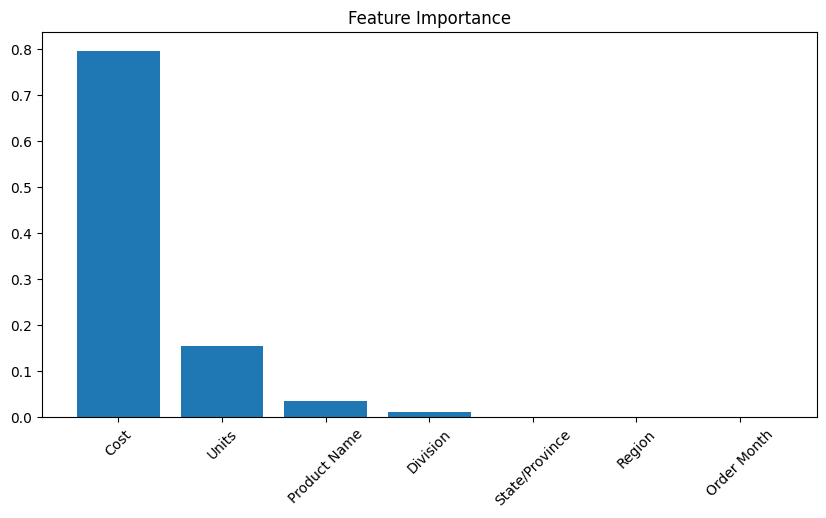

In [11]:
#ml preprocessing 
features = [
    "Region",
    "Division",
    "Product Name",
    "State/Province",
    "Units",
    "Cost",
    "Order Month"
]

target = "Gross Profit"

X = df[features]
y = df[target]

X.dtypes

#label Encoding
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()
categorical_cols = ["Region","Division","Product Name","State/Province"]

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

X.head()

#Train test split 
from sklearn.model_selection import train_test_split 

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

#feature scaling
from sklearn.preprocessing import StandardScaler
StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred =lr.predict(X_test)

#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

#random forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=20,random_state=42,n_jobs = -1)
rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Random Forest Results")
print("-" * 30)
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² Score:", r2_score(y_test, rf_pred))
df.shape

#comparing both models
print("Linear Regression R² :", r2_score(y_test, y_pred))
print("Random Forest R²     :", r2_score(y_test, rf_pred))
#feature importance
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [15]:
#model saving
import joblib

joblib.dump(rf, "factory_reallocation_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler Saved Successfully!")

loaded_model = joblib.load("factory_reallocation_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

print("Model Loaded Successfully!")

sample = X_test[:1]

prediction = loaded_model.predict(sample)

print("Predicted Gross Profit:", prediction)
print("Actual Gross Profit:", y_test.iloc[:1].values)


import joblib

joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")


loaded_model = joblib.load("random_forest_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

print("Model Loaded Successfully!")

sample = X_test[:5]

prediction = loaded_model.predict(sample)

print("Predictions:")
print(prediction)

print("\nActual Values:")
print(y_test.iloc[:5].values)

Model and Scaler Saved Successfully!
Model Loaded Successfully!
Predicted Gross Profit: [7.2]
Actual Gross Profit: [7.2]
Model Saved Successfully!
Model Loaded Successfully!
Predictions:
[7.2  2.45 7.35 9.6  7.5 ]

Actual Values:
[7.2  2.45 7.35 9.6  7.5 ]


In [ ]:
#factory reallocation system 
sample_order = [[
    2,      # Region
    1,      # Division
    150,    # Product Name (encoded)
    10,     # State/Province (encoded)
    25,     # Units
    120.50, # Cost
    6       # Order Month
]]

sample_order = loaded_scaler.transform(sample_order)

prediction = loaded_model.predict(sample_order)

print("Predicted Gross Profit:", prediction[0])



Predicted Gross Profit: 109.0


c:\Users\THOUSEEQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import sys
print(sys.executable)